In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import xarray as xr 
from datetime import datetime, date, timedelta
import plotly.graph_objects as go

In [2]:
f = "../data/001_raw/ERA5_Oaxaca_2023.nc"

oaxaca_2023 = xr.open_dataset(f)

f = "../data/001_raw/ERA5_Morelos_2023.nc"
morelos_2023 = xr.open_dataset(f)

In [3]:
#extraer una variable del formato .nc
def extraer_datos_oaxaca(variable="t2m"):
    
    return oaxaca_2023[variable]


def extraer_datos_morelos(variable="t2m"):
    
    return morelos_2023[variable]

In [4]:
df_oaxaca_2023 = oaxaca_2023.to_dataframe()
df_oaxaca_2023["t2m_Celsius"] = df_oaxaca_2023["t2m"] - 273

df_morelos_2023 = morelos_2023.to_dataframe()
df_morelos_2023["t2m_Celsius"] = df_morelos_2023["t2m"] - 273


<function matplotlib.pyplot.show(close=None, block=None)>

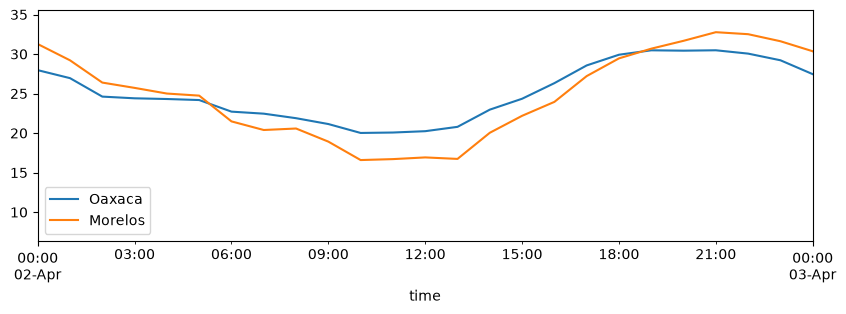

In [5]:
#obtener la temperatura promedio de todo oaxaca en un dia especifico 

t2m_promedio_oaxaca = df_oaxaca_2023.groupby(level="time")["t2m_Celsius"].mean()
t2m_promedio_morelos = df_morelos_2023.groupby(level="time")["t2m_Celsius"].mean()
f1 = pd.to_datetime("2023-04-02")
f2 = f1 + pd.Timedelta("1D")

fig, ax = plt.subplots(figsize =(10,3))
t2m_promedio_oaxaca.plot(label="Oaxaca")
t2m_promedio_morelos.plot(label = "Morelos")
ax.set_xlim(f1,f2)
ax.legend()
plt.show

In [6]:




fig = go.Figure()
fig.add_trace(go.Scatter(
    x=t2m_promedio_morelos.index,
    y=t2m_promedio_morelos.values,
    mode="lines",
    name="Morelos"
))

fig.add_trace(go.Scatter(
    x=t2m_promedio_oaxaca.index,
    y=t2m_promedio_oaxaca.values,
    mode="lines",
    name="Oaxaca"
))

fig.update_layout(title="Temperatura promedio de Morelos",
                  xaxis = dict(range=[f1,f2]),
                  yaxis_title ="temperatura",
                  xaxis_title ="tiempo"
                  )

fig.show()

In [7]:
#obtener la ubicacion de mi casa
casa = oaxaca_2023.sel(
    latitude = 17.023226,
    longitude = -96.757753,
    method="nearest"
).to_dataframe()


In [8]:
casa["t2m_Celsius"] = casa["t2m"] - 273

<Axes: xlabel='time'>

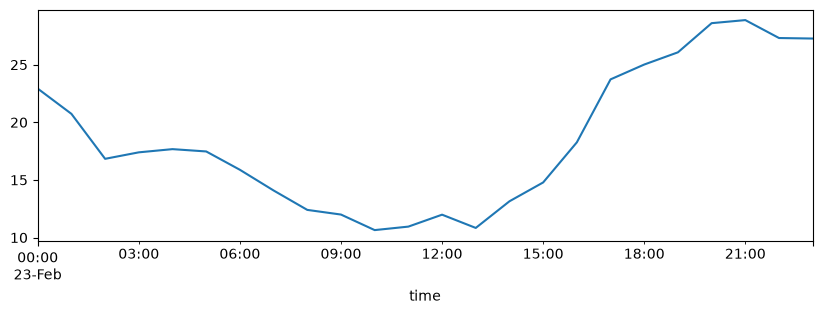

In [9]:
dia_temperatura = casa.loc["2023-02-23"]

dia_temperatura["t2m_Celsius"].plot(figsize=(10,3))

In [10]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=dia_temperatura.index,
    y=dia_temperatura["t2m_Celsius"],
    mode="lines",
    name="oaxaca"
))

fig.update_layout(title="Temperatura de un dia en casa de Johan",
                  yaxis_title ="temperatura",
                  xaxis_title ="tiempo"
                  )
